# 7.9 反向传播算法实战

本节我们将利用前面介绍的多层全连接网络的梯度推导结果，直接利用 Python 循环计
算每一层的梯度，并按着梯度下降算法手动更新。由于 TensorFlow 具有自动求导功能，我
们选择没有自动求导功能的 Numpy 实现网络，并利用 Numpy 手动计算梯度并手动更新网
络参数。
需要注意的是，本章推导的梯度传播公式是针对于多层全连接层，只有 Sigmoid 一种
激活函数，并且损失函数为均方误差函数的网络类型。对于其它类型的网络，比如激活函
数采用 ReLU，损失函数采用交叉熵的网络，需要重新推导梯度传播表达式，但是方法是
一样。正是因为手动推导梯度的方法局限性较大，在实践中采用极少，更多的是利用自动
求导工具计算。
我们将实现一个 4 层的全连接网络，来完成二分类任务。网络输入节点数为 2，隐藏
层的节点数设计为：25、50和25，输出层两个节点，分别表示属于类别 1 的概率和类别 2
的概率，如图 7.13 所示。这里并没有采用 Softmax 函数将网络输出概率值之和进行约束，
而是直接利用均方误差函数计算与 One-hot 编码的真实标签之间的误差，所有的网络激活
函数全部采用 Sigmoid 函数，这些设计都是为了能直接利用我们的梯度传播公式。

## 7.9.1 数据集

这里通过 scikit-learn 库提供的便捷工具生成 2000 个线性不可分的 2 分类数据集，数据
的特征长度为 2，采样出的数据分布如图 7.14 所示，所有的红色点为一类，所有的蓝色点
为一类，可以看到每个类别数据的分布呈月牙状，并且是是线性不可分的，无法用线性网
络获得较好效果。为了测试网络的性能，我们按着7: 3比例切分训练集和测试集，其中
2000 ∙ 0 3 = 600个样本点用于测试，不参与训练，剩下的 1400 个点用于网络的训练。

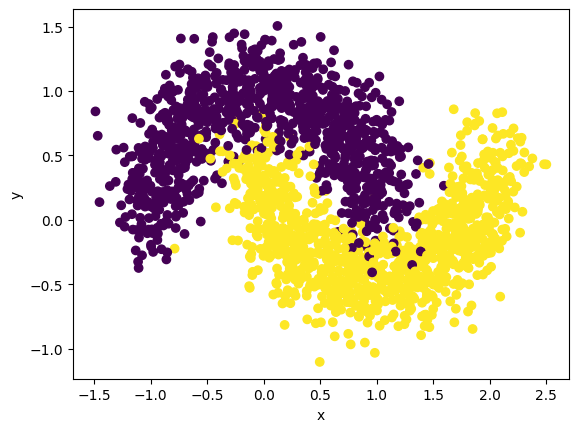

In [2]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

N_SAMPLES = 2000  # 采样点数
TEST_SIZE = 0.3  # 测试数量比例
# 利用工具函数直接生成数据集
X, y = make_moons(n_samples=2000, noise=0.2, random_state=100)
plt.scatter(X[:, 0], X[:, 1], c=y, label="数据集")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [3]:
from sklearn.model_selection import train_test_split
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=42)
print("训练集大小：", X_train.shape, y_train.shape)
print("测试集大小：", X_test.shape, y_test.shape)

训练集大小： (1400, 2) (1400,)
测试集大小： (600, 2) (600,)


## 7.9.2 网络层  
通过新建类 Layer 实现一个网络层，需要传入网络层的输入节点数、输出节点数、激
活函数类型等参数，权值 weights 和偏置张量 bias 在初始化时根据输入、输出节点数自动
生成并初始化。代码如下：

In [4]:
class Layer:
    # 全连接网络层
    def __init__(self, n_input, n_neurons, activation=None, weights=None, bias=None):
        """
        :param input_size: 输入节点数
        :param n_neurons: 输出节点数
        :param activation: 激活函数类型
        :param weights: 权值张量，默认内部类生成
        :param bias: 偏置张量，默认内部类生成

        """
        # 通过正态分布初始化网络权值，初始化非常重要，不合适的初始化将导致网络不收敛
        self.weights = weights if weights is not None else np.random.randn(
            n_input, n_neurons) * np.sqrt(1 / n_neurons)
        self.bias = bias if bias is not None else np.random.rand(
            n_neurons) * 0.1
        self.activation = activation  # 激活函数类型，如'sigmoid'、'tanh'或'linear'
        self.last_activation = None  # 激活函数的输出值 o
        self.error = None  # 用于计算梯度的误差项
        self.delta = None  # 记录当前层的 delta 变量，用于计算梯度

    # 网络层的前向传播函数实现如下，其中 last_activation 变量用于保存当前层的输出值：
    def activate(self, x):
        # 向前传播函数
        r = np.dot(x, self.weights) + self.bias  # x @ w + b
        self.last_activation = self._apply_activation(r)
        return self.last_activation

    # 上述代码中的 self._apply_activation 函数实现了不同类型的激活函数的前向计算过程，尽管
    # 此处我们只使用 Sigmoid 激活函数一种。代码如下：

    def _apply_activation(self, r):
        # 计算激活函数的输出
        if self.activation is None:
            return r  # 无激活函数
        # ReLU激活函数
        elif self.activation == 'relu':
            return np.maximum(r, 0)
        # tanh激活函数
        elif self.activation == 'tanh':
            return np.tanh(r)
        # sigmoid激活函数
        elif self.activation == 'sigmoid':
            return 1 / (1 + np.exp(-r))  # Sigmoid激活函数
        return r

    # 针对于不同类型的激活函数，它们的导数计算实现如下：
    def apply_activation_derivative(self, r):
        # 计算激活函数的导数
        if self.activation is None:
            return np.ones_like(r)  # 无激活函数的导数为1
        # ReLU激活函数的导数
        elif self.activate == 'relu':
            grad = np.array(r, copy=True)
            grad[r > 0] = 1.
            grad[r <= 0] = 0.
            return grad
        # tanh激活函数的导数
        elif self.activation == 'tanh':
            return 1 - np.tanh(r) ** 2  # tanh激活函数的导数
        # sigmoid激活函数的导数
        elif self.activation == 'sigmoid':
            return r * (1 - r)  # sigmoid激活函数的导数

        return r


## 7.9.3 网络模型
创建单层网络类后，我们实现网络模型的 NeuralNetwork 类，它内部维护各层的网络层 Layer 类对象，可以通过 add_layer 函数追加网络层，实现创建不同结构的网络模型目
的。代码如下

In [5]:
class NeuralNetwork:
    # 神经网络大类
    def __init__(self):
        self._layers = []  # 网络层对象列表

    def add_layer(self, layer: Layer):
        # 追加网络层
        self._layers.append(layer)

    # 网络的前向传播只需要循环调各个网络层对象的前向计算函数即可
    def feed_forward(self, X):
        # 向前传播
        for layer in self._layers:
            # 依次通过各个网络层
            X = layer.activate(X)
        return X

    def backpropagation(self, X, y, learning_rate):
        # 反向传播算法实现
        # 前向计算，得到输出值
        output = self.feed_forward(X)
        for i in reversed(range(len(self._layers))):
            layer = self._layers[i]  # 得到当前层对象
            # 如果是输出层
            if layer == self._layers[-1]:
                layer.error = y - output
                # 关键步骤：计算最后一层的delta，参考输出层的梯度公式
                layer.delta = layer.error * layer.apply_activation_derivative(output)
            else:  # 如果是隐藏层
                next_layer = self._layers[i + 1]  # 得到下一层的对象
                layer.error = np.dot(next_layer.weights, next_layer.delta)
                # 关键步骤：计算隐藏层的 delta，参考隐藏层的梯度公式
                layer.delta = layer.error * layer.apply_activation_derivative(layer.last_activation)
        # 循环更新权重
        for i in range(len(self._layers)):
            layer = self._layers[i]
            # o_i 为上一个网络层的输出
            o_i = np.atleast_2d(X if i == 0 else self._layers[i - 1].last_activation)




根据图 7.13 的网络结构配置，利用 NeuralNetwork 类创建网络对象，并添加 4 层全连
接层，代码如下：

In [6]:
nn = NeuralNetwork()  # 实例化网络类
nn.add_layer(Layer(2, 25, "sigmoid"))  # 隐藏层 1,2 => 25
nn.add_layer(Layer(25, 50, "sigmoid"))  # 隐藏层 2, 25=>50
nn.add_layer(Layer(25, 2, "sigmoid"))  # 输出层 25 => 2

网络模型的反向传播实现稍复杂，需要从最末层开始，计算每层的𝛿变量，然后根据推导出的梯度公式，将计算出的𝛿变量存储在 Layer 类的 delta 变量中。代码如下